In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("atp-output.csv")
df

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,player_A_surface_advantage,player_B_surface_advantage,predict_proba_R,predict_R
0,20240527,Roland Garros,Clay,True,Richard Gasquet,Jannik Sinner,1428.232372,1990.804394,0,-562.572022,-0.042954,-0.061038,0.009376,0
1,20240304,Indian Wells Masters,Hard,False,Luca Nardi,Novak Djokovic,1426.978358,1988.387409,1,-561.409051,0.033333,0.021161,0.048150,0
2,20240527,Roland Garros,Clay,True,Christopher Eubanks,Jannik Sinner,1460.358870,1994.272135,0,-533.913265,-0.333333,-0.061038,0.002623,0
3,20240115,Australian Open,Hard,True,Dino Prizmic,Novak Djokovic,1469.345775,1989.501544,0,-520.155770,-0.106061,0.021161,0.006175,0
4,20240304,Indian Wells Masters,Hard,False,Aleksandar Vukic,Novak Djokovic,1456.782265,1959.527077,0,-502.744812,-0.014892,0.021161,0.051192,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8974,20230807,Canada Masters,Hard,False,Carlos Alcaraz,Ben Shelton,1975.328955,1435.350501,1,539.978454,-0.051788,0.037636,0.919738,1
8975,20230814,Cincinnati Masters,Hard,False,Carlos Alcaraz,Max Purcell,1959.410011,1415.840627,1,543.569384,-0.051788,0.000591,0.934657,1
8976,20240826,Us Open,Hard,True,Jannik Sinner,Mackenzie Mcdonald,2031.389821,1487.493427,1,543.896394,0.024170,0.040074,0.989084,1
8977,20241121,Davis Cup Finals QF: ITA vs ARG,Hard,False,Jannik Sinner,Sebastian Baez,2078.072839,1533.139149,1,544.933689,0.024170,-0.211628,0.985589,1


### Players that performed well in best of five set matches

In [35]:
# Step 1: Filter to only five-set matches
five_set_df = df[df['five_set'] == True]

# Step 2: Create long-form for player A
player_A = five_set_df[['player_A_name', 'player_A_win']].rename(
    columns={'player_A_name': 'player', 'player_A_win': 'win'}
)

# Step 3: Create long-form for player B (if A wins, B loses and vice versa)
player_B = five_set_df[['player_B_name', 'player_A_win']].rename(
    columns={'player_B_name': 'player'}
)
player_B['win'] = 1 - player_B['player_A_win']

# Step 4: Combine both
players_long = pd.concat([player_A, player_B], ignore_index=True)

# Step 5: Calculate win rate per player
win_rate_df = players_long.groupby('player').agg(
    matches_played=('win', 'count'),
    matches_won=('win', 'sum')
).reset_index()

win_rate_df['win_rate'] = win_rate_df['matches_won'] / win_rate_df['matches_played']

# Optional: sort by win rate
win_rate_df = win_rate_df.sort_values(by='win_rate', ascending=False)

win_rate_df.head(10)


,player,matches_played,matches_won,win_rate
207,Novak Djokovic,61,55,0.901639
44,Carlos Alcaraz,59,52,0.881356
224,Rafael Nadal,27,23,0.851852
133,Jannik Sinner,59,49,0.830508
61,Daniil Medvedev,54,43,0.796296
16,Alexander Zverev,48,38,0.791667
200,Nick Kyrgios,13,10,0.769231
46,Casper Ruud,44,33,0.750000
23,Andrey Rublev,44,33,0.750000
183,Marin Cilic,15,11,0.733333


### Calculating top 10 players' elo over time

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

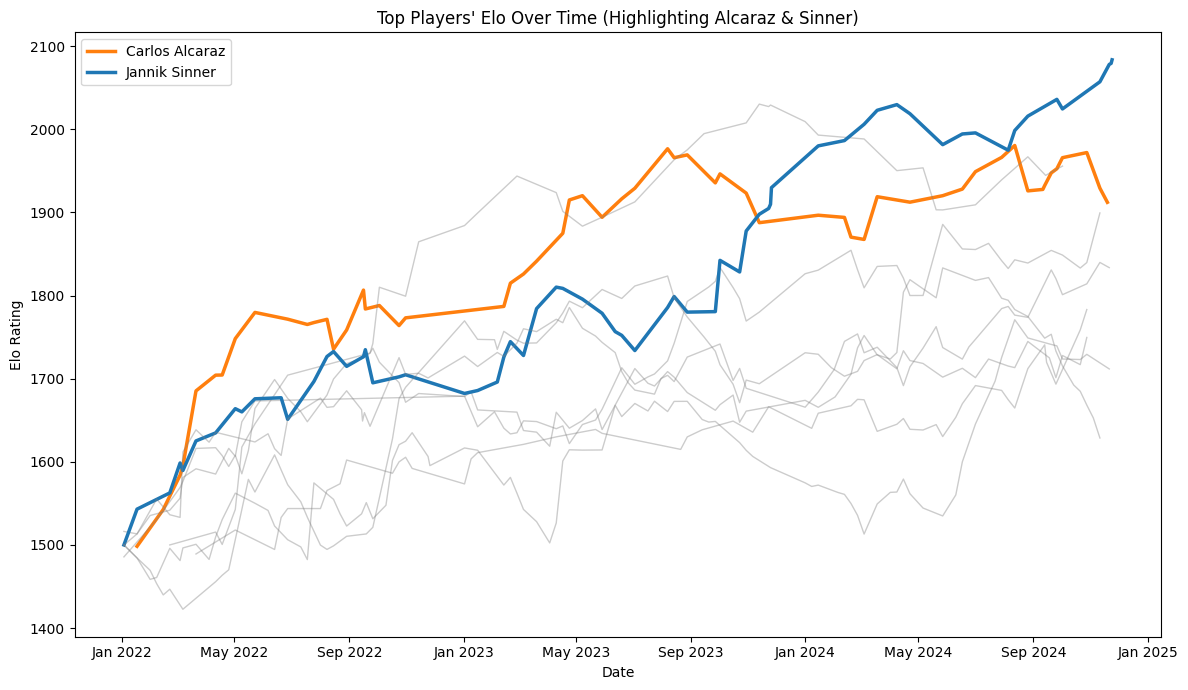

In [24]:


# Filter to matches before 2025
df = df[df['date'].dt.year < 2025]

# Define top 10 players
top_players = [
    "Carlos Alcaraz", "Novak Djokovic", "Casper Ruud",
    "Alexander Zverev", "Jack Draper", "Jannik Sinner", "Alex de Minaur",
    "Taylor Fritz", "Holger Rune", "Lorenzo Musetti"]


# Gather Elo data
elo_a = df[df['player_A_name'].isin(top_players)][['date', 'player_A_name', 'player_A_elo_before']].rename(
    columns={'player_A_name': 'player', 'player_A_elo_before': 'elo'}
)
elo_b = df[df['player_B_name'].isin(top_players)][['date', 'player_B_name', 'player_B_elo_before']].rename(
    columns={'player_B_name': 'player', 'player_B_elo_before': 'elo'}
)
elo_df = pd.concat([elo_a, elo_b]).drop_duplicates(subset=['player', 'date'])

# Plot Elo over time
plt.figure(figsize=(12, 7))
for player in top_players:
    player_data = elo_df[elo_df['player'] == player].sort_values(by='date')
    color = 'tab:orange' if player == 'Carlos Alcaraz' else \
            'tab:blue' if player == 'Jannik Sinner' else 'gray'
    linewidth = 2.5 if player in ['Carlos Alcaraz', 'Jannik Sinner'] else 1
    alpha = 1.0 if player in ['Carlos Alcaraz', 'Jannik Sinner'] else 0.4
    plt.plot(player_data['date'], player_data['elo'], label=player if player in ['Carlos Alcaraz', 'Jannik Sinner'] else None, color=color, linewidth=linewidth, alpha=alpha)

# Format and display
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(False)
plt.title("Top Players' Elo Over Time (Highlighting Alcaraz & Sinner)")
plt.xlabel("Date")
plt.ylabel("Elo Rating")
plt.legend()
plt.tight_layout()
plt.savefig("elo_plot.svg", format="svg")


### Alcaraz and Sinner in H2H against other top 10 players

In [4]:
top_players = [
    "Carlos Alcaraz", "Novak Djokovic", "Casper Ruud",
    "Alexander Zverev", "Jack Draper", "Jannik Sinner", "Alex de Minaur",
    "Taylor Fritz", "Holger Rune", "Lorenzo Musetti"
]

# Define target players
target_players = ["Carlos Alcaraz", "Jannik Sinner"]

# Filter for:
# - Alcaraz or Sinner vs another top player (not themselves)
# - Alcaraz vs Sinner matches
filtered_df = clay_df[
    (
        (clay_df['player_A_name'].isin(target_players)) &
        (clay_df['player_B_name'].isin(top_players)) &
        ((clay_df['player_B_name'] != clay_df['player_A_name']))
    ) |
    (
        (clay_df['player_B_name'].isin(target_players)) &
        (clay_df['player_A_name'].isin(top_players)) &
        ((clay_df['player_B_name'] != clay_df['player_A_name']))
    )
]
filtered_df

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,player_A_surface_advantage,player_B_surface_advantage,predict_proba_R,predict_R
181,20220718,Hamburg,Clay,False,Lorenzo Musetti,Carlos Alcaraz,1482.372000,1774.823596,1,-292.451596,0.066487,0.040070,0.188750,0
230,20230529,Roland Garros,Clay,True,Lorenzo Musetti,Carlos Alcaraz,1614.268468,1889.828862,0,-275.560394,0.066487,0.040070,0.098989,0
628,20220502,Madrid Masters,Clay,False,Novak Djokovic,Carlos Alcaraz,1542.687846,1731.085125,0,-188.397279,-0.054635,0.040070,0.177920,0
1193,20220502,Madrid Masters,Clay,False,Alexander Zverev,Carlos Alcaraz,1606.672687,1738.664776,0,-131.992088,0.047533,0.040070,0.334172,0
1860,20220725,Umag,Clay,False,Jannik Sinner,Carlos Alcaraz,1696.614680,1786.320102,1,-89.705421,-0.061038,0.040070,0.263066,0
2060,20240527,Roland Garros,Clay,True,Carlos Alcaraz,Jannik Sinner,1920.152874,1999.942823,1,-79.789949,0.040070,-0.061038,0.465641,0
2300,20220411,Monte Carlo Masters,Clay,False,Alexander Zverev,Jannik Sinner,1585.277817,1652.662706,1,-67.384889,0.047533,-0.061038,0.552888,1
2670,20240527,Roland Garros,Clay,True,Alexander Zverev,Carlos Alcaraz,1885.659012,1938.538373,0,-52.879361,0.047533,0.040070,0.395836,0
2790,20230410,Monte Carlo Masters,Clay,False,Holger Rune,Jannik Sinner,1767.285080,1815.730097,1,-48.445017,0.032293,-0.061038,0.558453,1
3056,20240729,Paris Olympics,Clay,False,Novak Djokovic,Carlos Alcaraz,1939.217079,1978.298093,1,-39.081014,-0.054635,0.040070,0.326823,0


## Player win % on clay

In [5]:

clay_df = df[df['surface'] == 'Clay'].copy()

#rearranging data so each row is one player per match
player_A = clay_df[['player_A_name', 'player_A_win']].copy()
player_A = player_A.rename(columns={'player_A_name': 'player', 'player_A_win': 'won'})

#doing the same for player_B
player_B = clay_df[['player_B_name', 'player_A_win']].copy()
player_B['won'] = 1 - player_B['player_A_win']
player_B = player_B.rename(columns={'player_B_name': 'player'})
player_B = player_B[['player', 'won']]

#now combining them
clay_long = pd.concat([player_A, player_B], ignore_index=True)

#now calculating win percent but only of players who have played more than 20 matches on clay to get a fair win pct
clay_win_pct = (
    clay_long.groupby('player')['won']
    .agg(matches='count', wins='sum')
    .query('matches > 20')  
    .assign(win_pct=lambda x: x['wins'] / x['matches'])
    .reset_index()
    .sort_values('win_pct', ascending=False)
)

clay_win_pct.head(10)  # top 10 players by clay win %


,player,matches,wins,win_pct
20,Carlos Alcaraz,80,69,0.862500
67,Matteo Berrettini,25,21,0.840000
70,Novak Djokovic,54,43,0.796296
84,Stefanos Tsitsipas,71,56,0.788732
7,Alexander Zverev,78,60,0.769231
21,Casper Ruud,94,72,0.765957
51,Jannik Sinner,45,34,0.755556
10,Andrey Rublev,61,44,0.721311
76,Rafael Nadal,28,20,0.714286
28,Daniil Medvedev,34,24,0.705882


## Alcaraz and Sinner against top 10 players on clay

In [7]:
def get_player_h2h(df, player_name, opponents):
    h2h_df = df[
        (
            (df['player_A_name'] == player_name) & (df['player_B_name'].isin(opponents)) &
            (df['player_B_name'] != player_name)
        ) |
        (
            (df['player_B_name'] == player_name) & (df['player_A_name'].isin(opponents)) &
            (df['player_A_name'] != player_name)
        )
    ].copy()

    h2h_df['opponent'] = h2h_df.apply(
        lambda row: row['player_B_name'] if row['player_A_name'] == player_name else row['player_A_name'],
        axis=1
    )

    h2h_df['player_win'] = h2h_df.apply(
        lambda row: row['player_A_win'] if row['player_A_name'] == player_name else 1 - row['player_A_win'],
        axis=1
    )

    summary = (
        h2h_df.groupby('opponent')['player_win']
        .agg(total_matches='count', wins='sum')
        .assign(win_pct=lambda x: (x['wins'] / x['total_matches'] * 100).round(1))
        .reset_index()
    )
    summary['player'] = player_name
    return summary[['player', 'opponent', 'total_matches', 'wins', 'win_pct']]


clay_df = df[df['surface'] == 'Clay'].copy()
top_players = [
    "Carlos Alcaraz", "Novak Djokovic", "Casper Ruud",
    "Alexander Zverev", "Jack Draper", "Jannik Sinner", "Alex de Minaur",
    "Taylor Fritz", "Holger Rune", "Lorenzo Musetti"
]

# Get H2H for both players
alcaraz_h2h = get_player_h2h(clay_df, "Carlos Alcaraz", top_players)
sinner_h2h = get_player_h2h(clay_df, "Jannik Sinner", top_players)

# Combine
combined_h2h = pd.concat([alcaraz_h2h, sinner_h2h], ignore_index=True)

combined_h2h


,player,opponent,total_matches,wins,win_pct
0,Carlos Alcaraz,Alexander Zverev,4,3,75.0
1,Carlos Alcaraz,Jannik Sinner,2,1,50.0
2,Carlos Alcaraz,Lorenzo Musetti,2,1,50.0
3,Carlos Alcaraz,Novak Djokovic,3,1,33.3
4,Jannik Sinner,Alexander Zverev,1,0,0.0
5,Jannik Sinner,Carlos Alcaraz,2,1,50.0
6,Jannik Sinner,Holger Rune,2,1,50.0
7,Jannik Sinner,Lorenzo Musetti,2,1,50.0


### Calculating top 10 Players' Elo over time

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8979 entries, 0 to 8978
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        8979 non-null   int64  
 1   tournament                  8979 non-null   object 
 2   surface                     8926 non-null   object 
 3   five_set                    8979 non-null   bool   
 4   player_A_name               8979 non-null   object 
 5   player_B_name               8979 non-null   object 
 6   player_A_elo_before         8979 non-null   float64
 7   player_B_elo_before         8979 non-null   float64
 8   player_A_win                8979 non-null   int64  
 9   elo_difference              8979 non-null   float64
 10  player_A_surface_advantage  8979 non-null   float64
 11  player_B_surface_advantage  8979 non-null   float64
 12  predict_proba_R             8979 non-null   float64
 13  predict_R                   8979 

## Possible upsets for Alcaraz or Sinner: players who have caused upsets in longer 5-set matches

### First, I calculated which players have caused upsets against Alcaraz and Sinner on either a clay surface or a five-set match. The result was Matteo Berrettini for five set matches and Lorenzo Musetti for clay. So then I expanded the df and looked at each of those matches individually to see if either of those matches fulfilled these conditions: 
#### a) the match was played on clay
#### b) the match was a best of five match
#### c) the match was played on clay AND was a best of five match (this would pose a serious threat to Sinner and Alcaraz)

### The result was that while some matches fulfilled condition a and b, none fulfilled c

In [43]:
# Step 1: Filter to long matches (five-set matches)
long_matches = df[df['five_set'] == True].copy()

# Step 2: Keep only cases where the predicted loser actually won
long_upsets = long_matches[
    ((long_matches['predict_R'] == 0) & (long_matches['player_A_win'] == 1)) |  # A upset
    ((long_matches['predict_R'] == 1) & (long_matches['player_A_win'] == 0))    # B upset
].copy()

# Step 3: Get the winning player who caused the upset
long_upsets['winning_player'] = long_upsets.apply(
    lambda row: row['player_A_name'] if row['player_A_win'] == 1 else row['player_B_name'],
    axis=1
)

# Step 4: Count upset wins in five-set matches
upset_counts = long_upsets['winning_player'].value_counts().reset_index()
upset_counts.columns = ['player', 'upset_wins_in_five_sets']

highest_long_upsets = long_upsets[
    (long_upsets['player_A_name'] == 'Matteo Berrettini') |
    (long_upsets['player_B_name'] == 'Matteo Berrettini')
].copy()

highest_long_upsets

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,player_A_surface_advantage,player_B_surface_advantage,predict_proba_R,predict_R,winning_player
662,20230828,Us Open,Hard,True,Arthur Rinderknech,Matteo Berrettini,1463.039421,1647.316317,1,-184.276896,0.035494,-0.104247,0.304058,0,Arthur Rinderknech
2090,20230828,Us Open,Hard,True,Ugo Humbert,Matteo Berrettini,1547.169202,1625.031112,0,-77.861910,0.071419,-0.104247,0.564478,1,Matteo Berrettini
2140,20230703,Wimbledon,Grass,True,Matteo Berrettini,Alexander Zverev,1636.572177,1711.482358,1,-74.910181,0.106933,0.011635,0.461458,0,Matteo Berrettini
2366,20220829,Us Open,Hard,True,Andy Murray,Matteo Berrettini,1565.445696,1630.168781,0,-64.723084,0.010204,-0.104247,0.511509,1,Matteo Berrettini
3070,20220117,Australian Open,Hard,True,Matteo Berrettini,Pablo Carreno Busta,1501.211841,1539.446931,1,-38.235090,-0.104247,0.039024,0.247605,0,Matteo Berrettini
3544,20220117,Australian Open,Hard,True,Brandon Nakashima,Matteo Berrettini,1513.176322,1536.630248,0,-23.453926,0.007342,-0.104247,0.593594,1,Matteo Berrettini
4919,20220117,Australian Open,Hard,True,Carlos Alcaraz,Matteo Berrettini,1500.000000,1485.590071,0,14.409929,-0.051788,-0.104247,0.595087,1,Matteo Berrettini
5232,20220117,Australian Open,Hard,True,Matteo Berrettini,Stefan Kozlov,1522.604801,1500.000000,1,22.604801,-0.104247,0.066667,0.321263,0,Matteo Berrettini
6047,20220117,Australian Open,Hard,True,Gael Monfils,Matteo Berrettini,1567.083374,1517.855951,0,49.227423,0.038082,-0.104247,0.760310,1,Matteo Berrettini
6122,20230703,Wimbledon,Grass,True,Alex De Minaur,Matteo Berrettini,1675.177951,1623.264702,0,51.913249,0.037963,0.106933,0.508561,1,Matteo Berrettini


### Possible upsets for Alcaraz and Sinner, according to clay surface

In [44]:
# Step 1: Filter to long matches (five-set matches)
long_matches = df[df['surface'] == 'Clay'].copy()

# Step 2: Keep only cases where the predicted loser actually won
long_upsets = long_matches[
    ((long_matches['predict_R'] == 0) & (long_matches['player_A_win'] == 1)) |  # A upset
    ((long_matches['predict_R'] == 1) & (long_matches['player_A_win'] == 0))    # B upset
].copy()

# Step 3: Get the winning player who caused the upset
long_upsets['winning_player'] = long_upsets.apply(
    lambda row: row['player_A_name'] if row['player_A_win'] == 1 else row['player_B_name'],
    axis=1
)

# Step 4: Count upset wins in five-set matches
upset_counts = long_upsets['winning_player'].value_counts().reset_index()
upset_counts.columns = ['player', 'upset_wins_in_five_sets']

highest_clay_upsets = long_upsets[
    (long_upsets['player_A_name'] == 'Lorenzo Musetti') |
    (long_upsets['player_B_name'] == 'Lorenzo Musetti')
].copy()

highest_clay_upsets

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,player_A_surface_advantage,player_B_surface_advantage,predict_proba_R,predict_R,winning_player
51,20230410,Monte Carlo Masters,Clay,False,Lorenzo Musetti,Novak Djokovic,1526.397270,1926.082200,1,-399.684930,0.065897,-0.053704,0.175373,0,Lorenzo Musetti
181,20220718,Hamburg,Clay,False,Lorenzo Musetti,Carlos Alcaraz,1482.372000,1774.823596,1,-292.451596,0.065897,0.040070,0.186134,0,Lorenzo Musetti
1194,20240729,Paris Olympics,Clay,False,Lorenzo Musetti,Alexander Zverev,1725.538652,1857.515361,1,-131.976710,0.065897,0.047533,0.343453,0,Lorenzo Musetti
1497,20230227,Santiago,Clay,False,Jaume Munar,Lorenzo Musetti,1452.879057,1562.293502,1,-109.414445,0.077295,0.065897,0.362412,0,Jaume Munar
1498,20230213,Buenos Aires,Clay,False,Juan Pablo Varillas,Lorenzo Musetti,1482.220995,1591.619053,1,-109.398058,0.077273,0.065897,0.362404,0,Juan Pablo Varillas
1550,20230424,Madrid Masters,Clay,False,Yannick Hanfmann,Lorenzo Musetti,1507.832780,1614.478095,1,-106.645315,0.047423,0.065897,0.330021,0,Yannick Hanfmann
2179,20230529,Roland Garros,Clay,True,Lorenzo Musetti,Cameron Norrie,1619.951019,1692.494506,1,-72.543487,0.065897,0.050253,0.363400,0,Lorenzo Musetti
2688,20240422,Madrid Masters,Clay,False,Thiago Seyboth Wild,Lorenzo Musetti,1509.844830,1561.614580,1,-51.769751,0.030560,0.065897,0.377392,0,Thiago Seyboth Wild
2724,20230410,Monte Carlo Masters,Clay,False,Lorenzo Musetti,Miomir Kecmanovic,1548.086572,1598.667092,1,-50.580520,0.065897,0.023665,0.480331,0,Lorenzo Musetti
3075,20220404,Marrakech,Clay,False,Laslo Djere,Lorenzo Musetti,1459.602565,1497.753469,1,-38.150904,0.012531,0.065897,0.372282,0,Laslo Djere
